# 05 - Customer Similarity kNN + K-Means Recommender

This notebook focuses on the customer-to-customer model. It uses kNN to find similar customers and K-Means to form customer groups.

In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

raw_dir = PROJECT_ROOT / "data" / "01_raw"
conversion_data = raw_dir / "conversion_data_july_2026.csv"
output_dir = PROJECT_ROOT / "data" / "05_customer_similarity_cf_outputs"
script_path = PROJECT_ROOT / "src" / "customer_to_customer_cf.py"

print("Project root:", PROJECT_ROOT)
print("Raw folder exists:", raw_dir.exists(), raw_dir)
print("Conversion data exists:", conversion_data.exists(), conversion_data)
print("Script exists:", script_path.exists(), script_path)

Project root: c:\Users\maheshsk\Downloads\Axis Int - Rec Sys\Coding
Raw folder exists: True c:\Users\maheshsk\Downloads\Axis Int - Rec Sys\Coding\data\01_raw
Conversion data exists: True c:\Users\maheshsk\Downloads\Axis Int - Rec Sys\Coding\data\01_raw\conversion_data_july_2026.csv
Script exists: True c:\Users\maheshsk\Downloads\Axis Int - Rec Sys\Coding\src\customer_to_customer_cf.py


In [3]:
import subprocess
import sys

output_dir.mkdir(parents=True, exist_ok=True)

cmd = [
    sys.executable, str(script_path),
    "--raw-dir", str(raw_dir),
    "--conversion-data", str(conversion_data),
    "--output-dir", str(output_dir),
    "--n-neighbors", "50",
    "--n-clusters", "6",
]

result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
if result.stderr:
    print(result.stderr)

Reading raw data from: C:\Users\maheshsk\Downloads\Axis Int - Rec Sys\Coding\data\01_raw
Writing outputs to: C:\Users\maheshsk\Downloads\Axis Int - Rec Sys\Coding\data\05_customer_similarity_cf_outputs

Done. Key outputs:
- C:\Users\maheshsk\Downloads\Axis Int - Rec Sys\Coding\data\05_customer_similarity_cf_outputs\final_top_3_recommendations_knn_customer_similarity.csv
- C:\Users\maheshsk\Downloads\Axis Int - Rec Sys\Coding\data\05_customer_similarity_cf_outputs\final_top_3_recommendations_cluster_based.csv
- C:\Users\maheshsk\Downloads\Axis Int - Rec Sys\Coding\data\05_customer_similarity_cf_outputs\final_top_3_recommendations_knn_cluster_blended.csv
- C:\Users\maheshsk\Downloads\Axis Int - Rec Sys\Coding\data\05_customer_similarity_cf_outputs\customer_clusters.csv
- C:\Users\maheshsk\Downloads\Axis Int - Rec Sys\Coding\data\05_customer_similarity_cf_outputs\cluster_profiles.csv
- C:\Users\maheshsk\Downloads\Axis Int - Rec Sys\Coding\data\05_customer_similarity_cf_outputs\knn_signal_

In [4]:
import pandas as pd

feature_metadata = pd.read_csv(output_dir / "customer_similarity_feature_metadata.csv")
accuracy = pd.read_csv(output_dir / "customer_similarity_model_accuracy_comparison.csv")
cluster_profiles = pd.read_csv(output_dir / "cluster_profiles.csv")
knn_signal = pd.read_csv(output_dir / "knn_signal_by_customer_product.csv")
neighbors = pd.read_csv(output_dir / "customer_similarity_neighbor_sample.csv")
knn_recs = pd.read_csv(output_dir / "final_top_3_recommendations_knn_customer_similarity.csv")
cluster_recs = pd.read_csv(output_dir / "final_top_3_recommendations_cluster_based.csv")
blended_recs = pd.read_csv(output_dir / "final_top_3_recommendations_knn_cluster_blended.csv")

print("Feature groups used in similarity")
display(feature_metadata)

print("Model accuracy comparison")
display(accuracy)

print("Cluster profiles")
display(cluster_profiles)

print("kNN signal sample")
display(knn_signal.head(20))

print("Nearest-neighbor sample with signal breakdown")
display(neighbors.head(20))

print("Final kNN recommendations")
display(knn_recs.head(20))

print("Final cluster-based recommendations")
display(cluster_recs.head(20))

print("Final blended recommendations")
display(blended_recs.head(20))

Feature groups used in similarity


,feature_group,feature_count,group_weight,columns_used
0,product_holdings,6,0.35,"PL, CC, HL, SA, RD, MF"
1,customer_numeric_profile,7,0.25,"Age, Mobile no., Risk profile score, Monthly i..."
2,digital_behavior,4,0.10,"digital_Days since last login (sn), digital_Lo..."
3,transaction_behavior,10,0.10,"txn_Average ticket size, txn_Count, txn_99% va..."
4,customer_categorical_profile,185,0.20,"Gender_F, Gender_M, Gender_O, Insta flag_N, In..."


Model accuracy comparison


,model,converted_customers,evaluated_conversion_rows,hit_rate_at_1,hit_rate_at_3,mrr,avg_rank_if_hit
0,kNN Customer Similarity,1118,1118,0.378354,0.865832,0.587955,1.799587
1,K-Means Cluster Product Affinity,1118,1118,0.409660,0.880143,0.611360,1.763211
2,kNN + K-Means Blended,1118,1118,0.395349,0.872093,0.600328,1.776410


Cluster profiles


...

,Customer ID,cluster_id,recommendation_model,recommendation_rank,product_code,Product_Name,knn_recommendation_score,knn_recommendation_score.1,cluster_recommendation_score,neighbor_support_count,avg_neighbor_similarity,top_neighbor_similarity,cluster_product_affinity_score
0,CUST1000000,2,kNN Customer Similarity,1,CC,Credit Card,0.344869,0.344869,0.520942,17,0.784093,0.896370,0.520942
1,CUST1000000,2,kNN Customer Similarity,2,RD,Recurring Deposit,0.262184,0.262184,0.217277,13,0.784093,0.896370,0.217277
2,CUST1000000,2,kNN Customer Similarity,3,PL,Personal Loan,0.100936,0.100936,0.159686,5,0.784093,0.896370,0.159686
3,CUST1000001,3,kNN Customer Similarity,1,CC,Credit Card,0.397836,0.397836,0.466472,20,0.751177,0.814736,0.466472
4,CUST1000001,3,kNN Customer Similarity,2,RD,Recurring Deposit,0.160943,0.160943,0.163000,8,0.751177,0.814736,0.163000
5,CUST1000001,3,kNN Customer Similarity,3,PL,Personal Loan,0.099563,0.099563,0.178903,5,0.751177,0.814736,0.178903
6,CUST1000002,0,kNN Customer Similarity,1,MF,Mutual Fund,0.316448,0.316448,0.405904,16,0.697620,0.755059,0.405904
7,CUST1000002,0,kNN Customer Similarity,2,RD,Recurring Deposit,0.160373,0.160373,0.239325,8,0.697620,0.755059,0.239325
8,CUST1000002,0,kNN Customer Similarity,3,HL,Home Loan,0.100093,0.100093,0.104902,5,0.697620,0.755059,0.104902
9,CUST1000003,1,kNN Customer Similarity,1,RD,Recurring Deposit,0.180524,0.180524,0.275233,9,0.703860,0.820594,0.275233


Final cluster-based recommendations


,Customer ID,cluster_id,recommendation_model,recommendation_rank,product_code,Product_Name,cluster_recommendation_score,knn_recommendation_score,cluster_recommendation_score.1,neighbor_support_count,avg_neighbor_similarity,top_neighbor_similarity,cluster_product_affinity_score
0,CUST1000000,2,K-Means Cluster Product Affinity,1,CC,Credit Card,0.520942,0.344869,0.520942,17,0.784093,0.896370,0.520942
1,CUST1000000,2,K-Means Cluster Product Affinity,2,RD,Recurring Deposit,0.217277,0.262184,0.217277,13,0.784093,0.896370,0.217277
2,CUST1000000,2,K-Means Cluster Product Affinity,3,PL,Personal Loan,0.159686,0.100936,0.159686,5,0.784093,0.896370,0.159686
3,CUST1000001,3,K-Means Cluster Product Affinity,1,CC,Credit Card,0.466472,0.397836,0.466472,20,0.751177,0.814736,0.466472
4,CUST1000001,3,K-Means Cluster Product Affinity,2,MF,Mutual Fund,0.230586,0.079508,0.230586,4,0.751177,0.814736,0.230586
5,CUST1000001,3,K-Means Cluster Product Affinity,3,PL,Personal Loan,0.178903,0.099563,0.178903,5,0.751177,0.814736,0.178903
6,CUST1000002,0,K-Means Cluster Product Affinity,1,MF,Mutual Fund,0.405904,0.316448,0.405904,16,0.697620,0.755059,0.405904
7,CUST1000002,0,K-Means Cluster Product Affinity,2,RD,Recurring Deposit,0.239325,0.160373,0.239325,8,0.697620,0.755059,0.239325
8,CUST1000002,0,K-Means Cluster Product Affinity,3,HL,Home Loan,0.104902,0.100093,0.104902,5,0.697620,0.755059,0.104902
9,CUST1000003,1,K-Means Cluster Product Affinity,1,RD,Recurring Deposit,0.275233,0.180524,0.275233,9,0.703860,0.820594,0.275233


Final blended recommendations


,Customer ID,cluster_id,recommendation_model,recommendation_rank,product_code,Product_Name,knn_cluster_blended_score,knn_recommendation_score,cluster_recommendation_score,neighbor_support_count,avg_neighbor_similarity,top_neighbor_similarity,cluster_product_affinity_score
0,CUST1000000,2,kNN + K-Means Blended,1,CC,Credit Card,0.397691,0.344869,0.520942,17,0.784093,0.896370,0.520942
1,CUST1000000,2,kNN + K-Means Blended,2,RD,Recurring Deposit,0.248712,0.262184,0.217277,13,0.784093,0.896370,0.217277
2,CUST1000000,2,kNN + K-Means Blended,3,PL,Personal Loan,0.118561,0.100936,0.159686,5,0.784093,0.896370,0.159686
3,CUST1000001,3,kNN + K-Means Blended,1,CC,Credit Card,0.418427,0.397836,0.466472,20,0.751177,0.814736,0.466472
4,CUST1000001,3,kNN + K-Means Blended,2,RD,Recurring Deposit,0.161560,0.160943,0.163000,8,0.751177,0.814736,0.163000
5,CUST1000001,3,kNN + K-Means Blended,3,MF,Mutual Fund,0.124831,0.079508,0.230586,4,0.751177,0.814736,0.230586
6,CUST1000002,0,kNN + K-Means Blended,1,MF,Mutual Fund,0.343285,0.316448,0.405904,16,0.697620,0.755059,0.405904
7,CUST1000002,0,kNN + K-Means Blended,2,RD,Recurring Deposit,0.184059,0.160373,0.239325,8,0.697620,0.755059,0.239325
8,CUST1000002,0,kNN + K-Means Blended,3,HL,Home Loan,0.101536,0.100093,0.104902,5,0.697620,0.755059,0.104902
9,CUST1000003,1,kNN + K-Means Blended,1,RD,Recurring Deposit,0.208937,0.180524,0.275233,9,0.703860,0.820594,0.275233


## Visualizations generated by the script

01_feature_group_weights.png


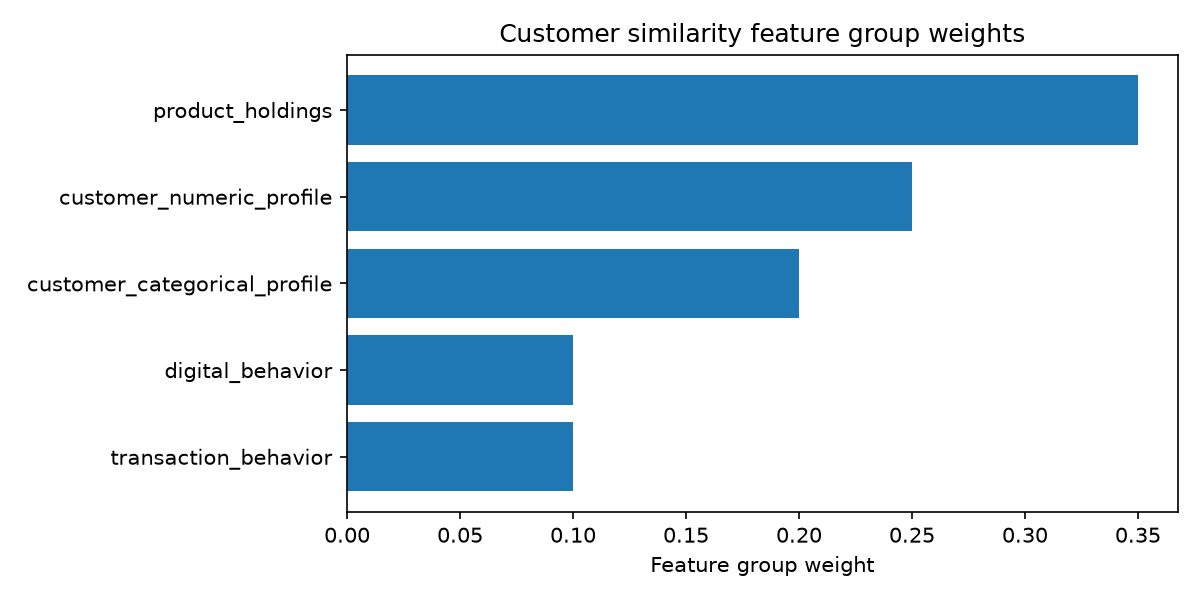

02_cluster_sizes.png


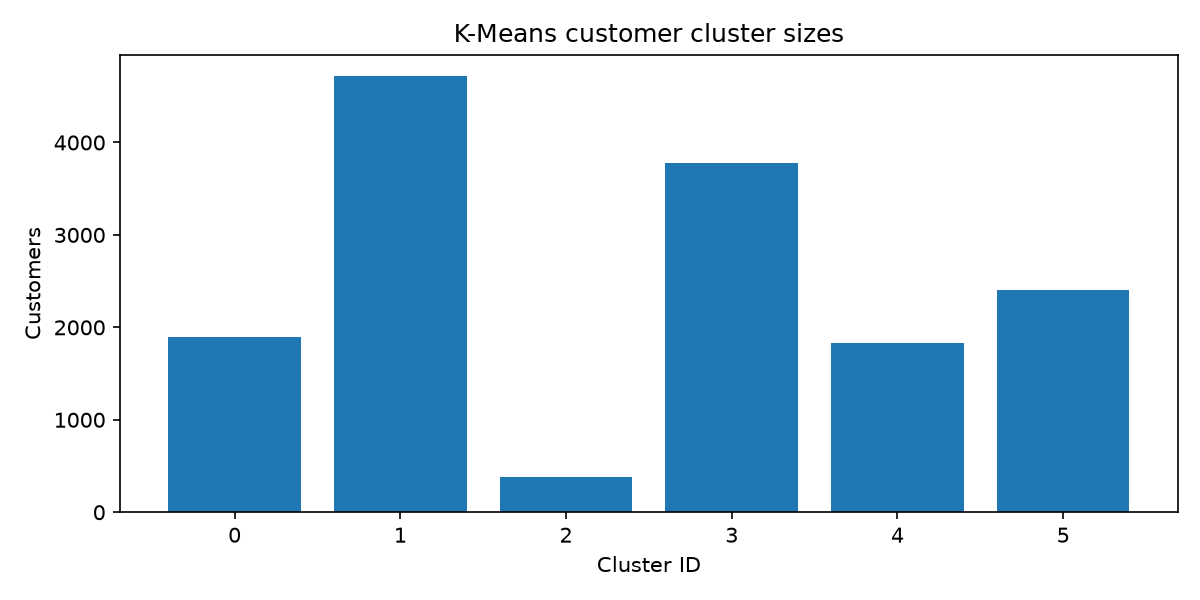

03_cluster_product_holding_rates.png


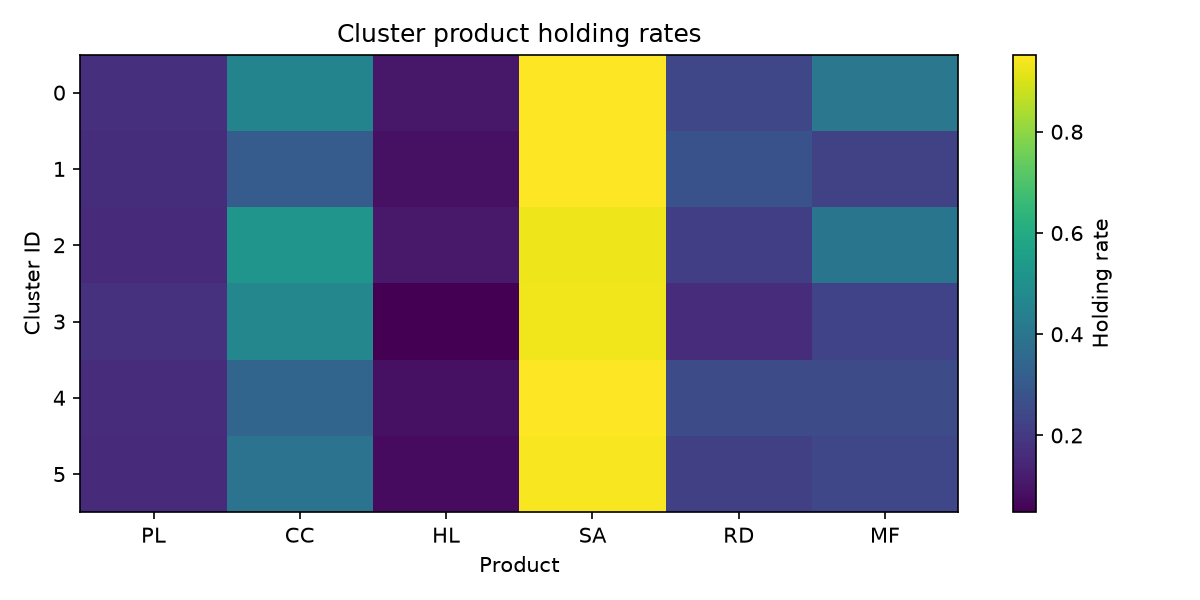

04_knn_signal_score_distribution.png


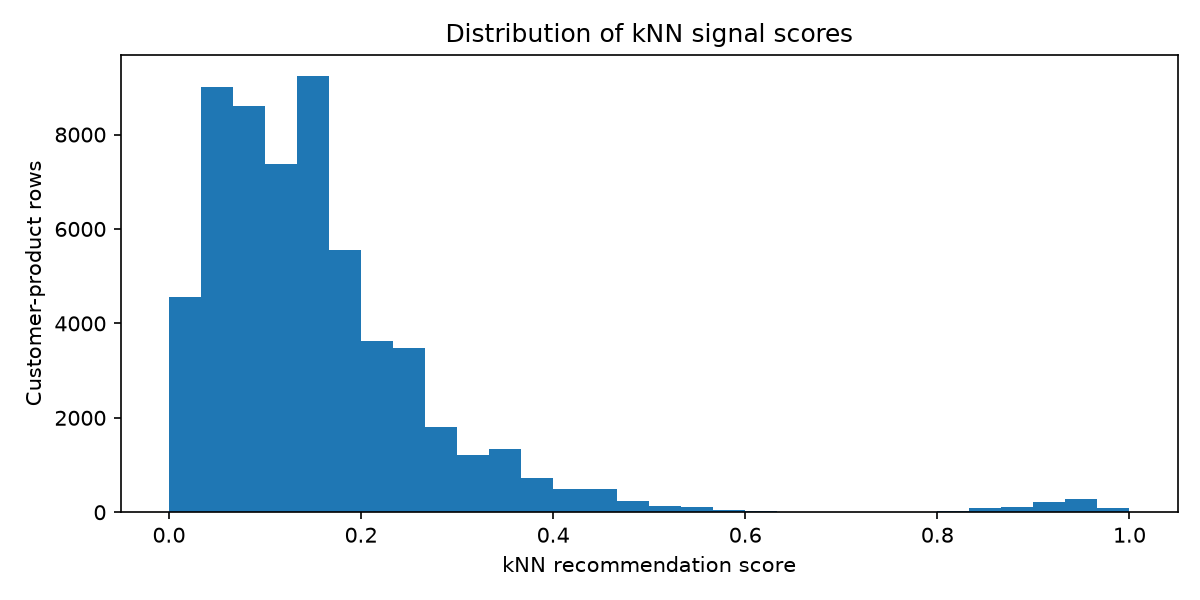

05_recommendation_mix_blended.png


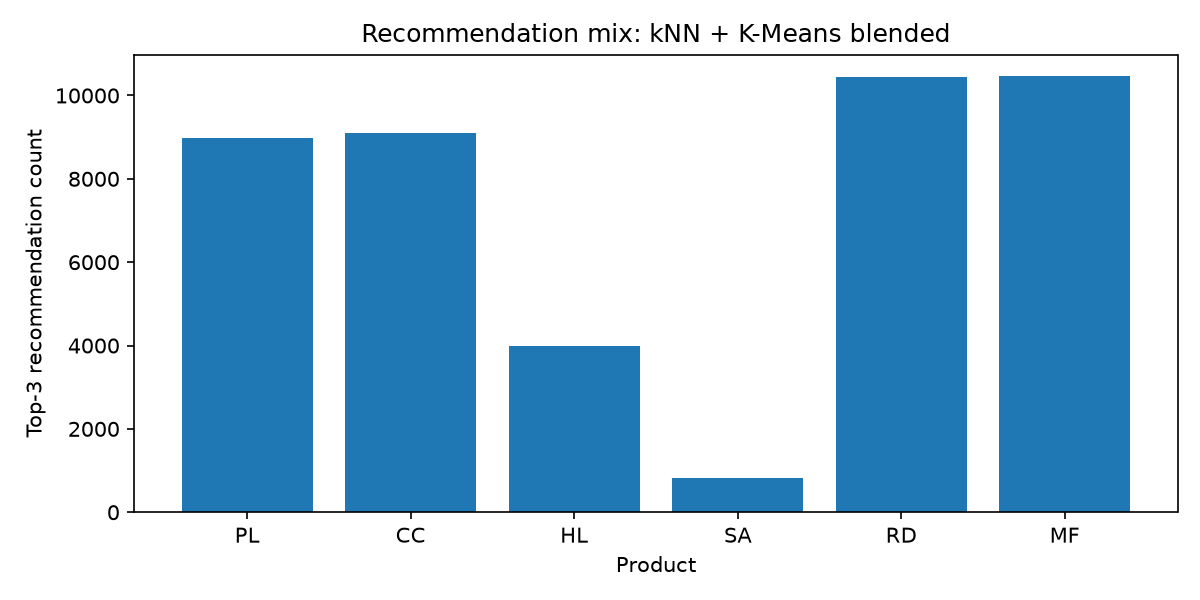

06_accuracy_comparison.png


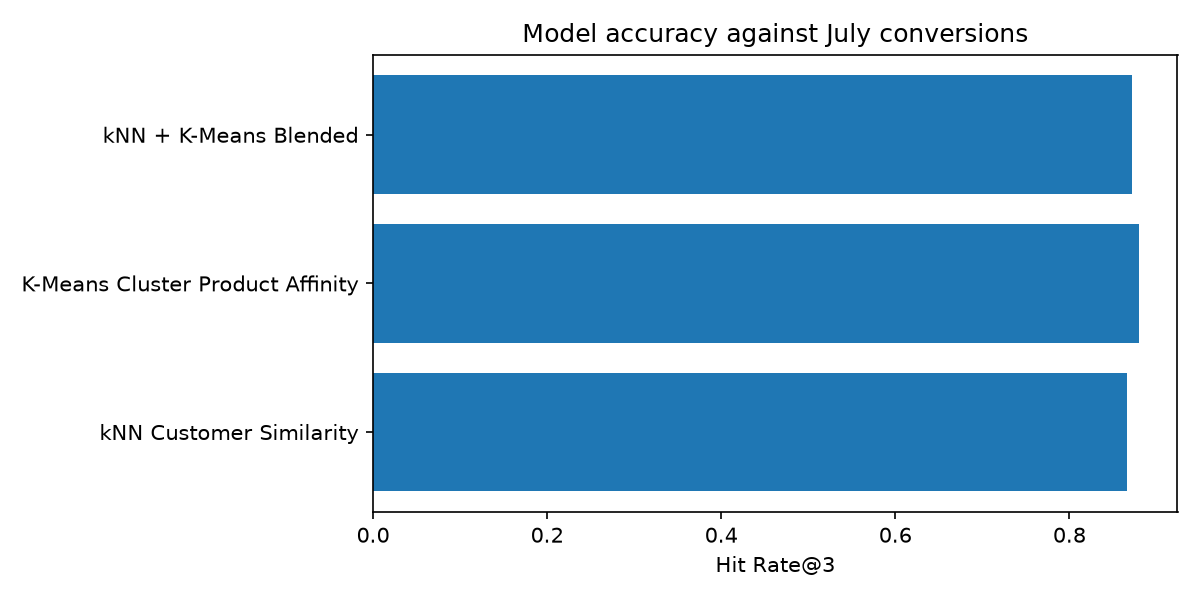

07_pca_customer_clusters.png


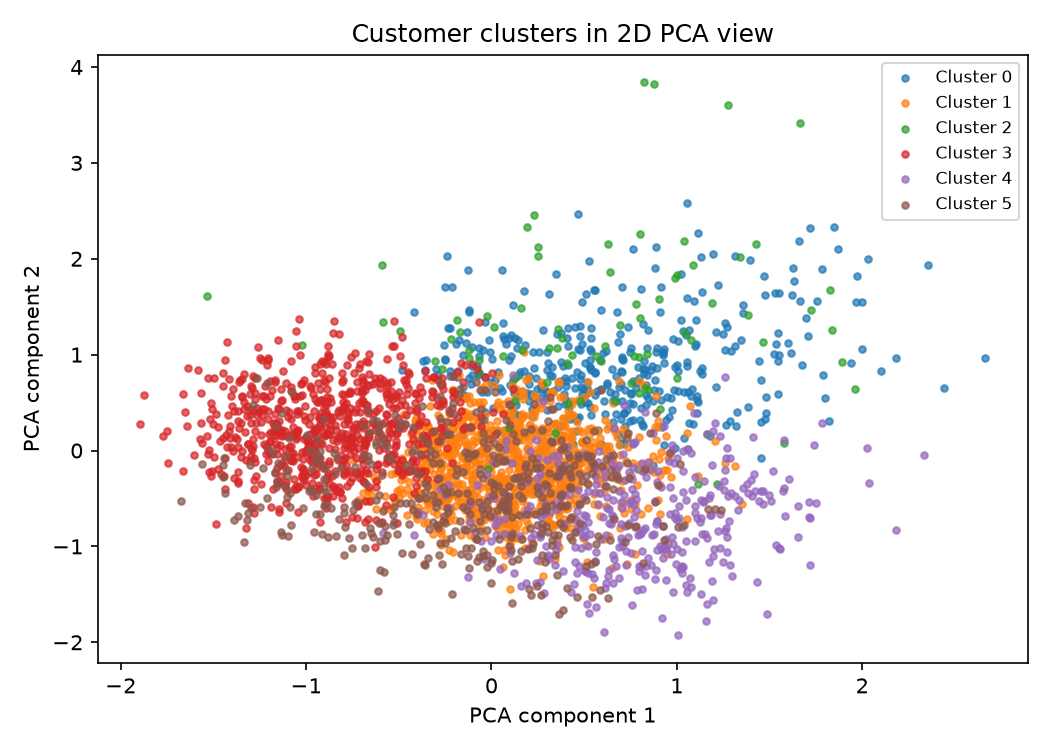

In [4]:
from IPython.display import Image, display

viz_dir = output_dir / "visualizations"
images = [
    "01_feature_group_weights.png",
    "02_cluster_sizes.png",
    "03_cluster_product_holding_rates.png",
    "04_knn_signal_score_distribution.png",
    "05_recommendation_mix_blended.png",
    "06_accuracy_comparison.png",
    "07_pca_customer_clusters.png",
]

for image in images:
    path = viz_dir / image
    if path.exists():
        print(image)
        display(Image(filename=str(path)))
    else:
        print("Missing:", image)